# Mini-Project 4: Rainfall Pattern & Crop Suitability Analyser

## Purpose
This project compares monthly rainfall in Kampala, Gulu and Mbarara
to explore seasonal patterns and rainfall-based crop suitability.

## Data and assumptions
Each region has twelve illustrative rainfall values in millimetres,
ordered from January to December. These values are supplied in the
assignment and are not verified climate observations.

Monthly totals describe rainfall quantity but do not reveal how rain
is distributed within a month. Crop suitability also depends on soil,
temperature, drainage, crop variety and growth stage.

## Approach
We summarise rainfall, compare regions using three similarity measures,
detect rainfall peaks and apply crop rainfall rules supported by sources.
The analysis concludes with charts and a short advisory note.

In [15]:
import sys
from pathlib import Path
import numpy as np

# Locate the project folder so Python can import from src.
project_folder = Path.cwd()
if not (project_folder / "src").is_dir():
    project_folder = project_folder.parent

sys.path.insert(0, str(project_folder))

from src.rainfall import Region

# Store the assignment's monthly rainfall in mm, January to December.
regions = {
    "Kampala": Region("Kampala", np.array([
        120, 140, 180, 200, 220, 180, 90, 70, 60, 100, 110, 130
    ])),
    "Gulu": Region("Gulu", np.array([
        8, 25, 75, 160, 190, 145, 170, 215, 175, 150, 60, 15
    ])),
    "Mbarara": Region("Mbarara", np.array([
        70, 85, 120, 140, 90, 25, 20, 55, 100, 125, 120, 90
    ]))
}

# Confirm that each region contains twelve monthly observations.
for name, region in regions.items():
    print(f"{name}: {len(region.rainfall)} monthly values loaded")

Kampala: 12 monthly values loaded
Gulu: 12 monthly values loaded
Mbarara: 12 monthly values loaded


## 1. Summarise monthly rainfall

For each region, we calculate annual rainfall, average monthly rainfall,
the wettest and driest months, and the coefficient of variation (CV).

CV expresses the population standard deviation of the twelve monthly
values relative to their mean. A higher CV indicates greater variation
between months, not greater year-to-year variability.

In [16]:
import pandas as pd

# Collect rainfall summaries using the Region object's methods.
rainfall_summary = []

for name, region in regions.items():
    rainfall_summary.append({
        "Region": name,
        "Annual total (mm)": region.annual_total(),
        "Monthly mean (mm)": region.mean(),
        "Wettest month": region.wettest_month(),
        "Driest month": region.driest_month(),
        "CV (%)": region.coefficient_of_variation() * 100
    })

# Display the comparison, rounding only the displayed values.
summary_table = pd.DataFrame(rainfall_summary)
display(summary_table.round(2))

,Region,Annual total (mm),Monthly mean (mm),Wettest month,Driest month,CV (%)
0,Kampala,1600.0,133.33,May,September,37.17
1,Gulu,1388.0,115.67,August,January,61.42
2,Mbarara,1040.0,86.67,April,July,42.48


## 2. Define rainfall screening rules for crops

FAO's “Crop Water Needs”, Table 14, gives indicative water requirements
over the whole growing period:

| Crop | Seasonal water need (mm) | Assumed duration | Derived monthly range (mm) |
|---|---:|---:|---:|
| Maize | 500–800 | 4 months | 125–200 |
| Beans | 300–500 | 3 months | 100–166.67 |
| Sorghum | 450–650 | 4 months | 112.5–162.5 |

For this exercise, we divide seasonal requirements by assumed growing
durations. These durations and the equal monthly allocation are modelling
choices, not FAO recommendations for monthly rainfall thresholds.

We use rainfall as a simplified proxy for available crop water, ignoring
runoff, irrigation and stored soil moisture. Actual water needs also
change with growth stage and climate.

“Good for” means within our chosen range. “Drought risk” means below it.
“Waterlogging risk” is an above-range screening flag only: exceeding a
crop's water requirement does not establish waterlogging, which also
depends on drainage and rainfall intensity.

Source: FAO, Chapter 3: Crop Water Needs, Table 14.
https://www.fao.org/4/s2022e/s2022e07.htm

In [17]:
import importlib
import src.rainfall as rainfall_module

# Reload the module to access the new CropRule class.
importlib.reload(rainfall_module)

# Derive monthly screening limits from the documented assumptions.
crop_rules = {
    "Maize": rainfall_module.CropRule("Maize", 500 / 4, 800 / 4),
    "Beans": rainfall_module.CropRule("Beans", 300 / 3, 500 / 3),
    "Sorghum": rainfall_module.CropRule("Sorghum", 450 / 4, 650 / 4)
}

# Check how each rule classifies an illustrative month with 140 mm.
for name, rule in crop_rules.items():
    print(f"{name}: 140 mm → {rule.classify(140)}")

Maize: 140 mm → Good for Maize
Beans: 140 mm → Good for Beans
Sorghum: 140 mm → Good for Sorghum


In [18]:
# Match the twelve rainfall values to their calendar months.
months = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

suitability_rows = []

# Apply all three crop rules to each month in each region.
for region_name, region in regions.items():
    for month, rainfall_mm in zip(months, region.rainfall):
        row = {
            "Region": region_name,
            "Month": month,
            "Rainfall (mm)": rainfall_mm
        }

        for crop_name, rule in crop_rules.items():
            row[crop_name] = rule.classify(float(rainfall_mm))

        suitability_rows.append(row)

# Store all classifications and display one table per region.
suitability_table = pd.DataFrame(suitability_rows)

for region_name in regions:
    print(f"\n{region_name}")
    display(
        suitability_table.loc[
            suitability_table["Region"] == region_name
        ].reset_index(drop=True)
    )


Kampala


,Region,Month,Rainfall (mm),Maize,Beans,Sorghum
0,Kampala,Jan,120.0,Drought risk,Good for Beans,Good for Sorghum
1,Kampala,Feb,140.0,Good for Maize,Good for Beans,Good for Sorghum
2,Kampala,Mar,180.0,Good for Maize,Waterlogging risk,Waterlogging risk
3,Kampala,Apr,200.0,Good for Maize,Waterlogging risk,Waterlogging risk
4,Kampala,May,220.0,Waterlogging risk,Waterlogging risk,Waterlogging risk
5,Kampala,Jun,180.0,Good for Maize,Waterlogging risk,Waterlogging risk
6,Kampala,Jul,90.0,Drought risk,Drought risk,Drought risk
7,Kampala,Aug,70.0,Drought risk,Drought risk,Drought risk
8,Kampala,Sep,60.0,Drought risk,Drought risk,Drought risk
9,Kampala,Oct,100.0,Drought risk,Good for Beans,Drought risk



Gulu


,Region,Month,Rainfall (mm),Maize,Beans,Sorghum
0,Gulu,Jan,8.0,Drought risk,Drought risk,Drought risk
1,Gulu,Feb,25.0,Drought risk,Drought risk,Drought risk
2,Gulu,Mar,75.0,Drought risk,Drought risk,Drought risk
3,Gulu,Apr,160.0,Good for Maize,Good for Beans,Good for Sorghum
4,Gulu,May,190.0,Good for Maize,Waterlogging risk,Waterlogging risk
5,Gulu,Jun,145.0,Good for Maize,Good for Beans,Good for Sorghum
6,Gulu,Jul,170.0,Good for Maize,Waterlogging risk,Waterlogging risk
7,Gulu,Aug,215.0,Waterlogging risk,Waterlogging risk,Waterlogging risk
8,Gulu,Sep,175.0,Good for Maize,Waterlogging risk,Waterlogging risk
9,Gulu,Oct,150.0,Good for Maize,Good for Beans,Good for Sorghum



Mbarara


,Region,Month,Rainfall (mm),Maize,Beans,Sorghum
0,Mbarara,Jan,70.0,Drought risk,Drought risk,Drought risk
1,Mbarara,Feb,85.0,Drought risk,Drought risk,Drought risk
2,Mbarara,Mar,120.0,Drought risk,Good for Beans,Good for Sorghum
3,Mbarara,Apr,140.0,Good for Maize,Good for Beans,Good for Sorghum
4,Mbarara,May,90.0,Drought risk,Drought risk,Drought risk
5,Mbarara,Jun,25.0,Drought risk,Drought risk,Drought risk
6,Mbarara,Jul,20.0,Drought risk,Drought risk,Drought risk
7,Mbarara,Aug,55.0,Drought risk,Drought risk,Drought risk
8,Mbarara,Sep,100.0,Drought risk,Good for Beans,Drought risk
9,Mbarara,Oct,125.0,Good for Maize,Good for Beans,Good for Sorghum


## 3. Compare rainfall using cosine similarity

Cosine similarity equals the dot product of two rainfall vectors divided
by the product of their lengths. Higher values indicate closer alignment.

It ignores overall scale: doubling every monthly value leaves cosine
similarity unchanged. Two regions can therefore have a similarity of 1
even if one receives twice as much rainfall.

SciPy returns cosine distance, so we subtract it from 1 to obtain
cosine similarity and check our implementation.

In [19]:
from scipy.spatial.distance import cosine

# Reload the module and recreate the objects with the new method.
importlib.reload(rainfall_module)
regions = {
    name: rainfall_module.Region(name, region.rainfall)
    for name, region in regions.items()
}

# Compare Kampala and Gulu using our method and SciPy.
our_similarity = regions["Kampala"].cosine_similarity(regions["Gulu"])
scipy_similarity = 1 - cosine(
    regions["Kampala"].rainfall,
    regions["Gulu"].rainfall
)

# Check agreement while allowing for floating-point rounding.
print(f"Our cosine similarity: {our_similarity:.6f}")
print(f"SciPy cosine similarity: {scipy_similarity:.6f}")
print("Results match:", np.isclose(our_similarity, scipy_similarity))

Our cosine similarity: 0.786609
SciPy cosine similarity: 0.786609
Results match: True


## 4. Compare three measures of rainfall similarity

Cosine similarity compares vector alignment and ignores overall scale.
Pearson correlation measures whether rainfall rises and falls together
across corresponding months. Both are dimensionless.

Euclidean distance measures the overall difference between monthly
rainfall values in millimetres. Smaller distances indicate closer values,
while larger cosine similarity and correlation indicate closer alignment.

In [20]:
# Prepare square matrices with one row and column per region.
region_names = list(regions)
count = len(region_names)

cosine_matrix = np.zeros((count, count))
correlation_matrix = np.zeros((count, count))
distance_matrix = np.zeros((count, count))

# Calculate all three measures for each pair of regions.
for i, first_name in enumerate(region_names):
    for j, second_name in enumerate(region_names):
        first = regions[first_name]
        second = regions[second_name]

        cosine_matrix[i, j] = first.cosine_similarity(second)
        correlation_matrix[i, j] = np.corrcoef(
            first.rainfall, second.rainfall
        )[0, 1]
        distance_matrix[i, j] = np.linalg.norm(
            first.rainfall - second.rainfall
        )

# Label the matrices and round only their displayed values.
for title, matrix in [
    ("Cosine similarity", cosine_matrix),
    ("Pearson correlation", correlation_matrix),
    ("Euclidean distance (mm)", distance_matrix)
]:
    print(f"\n{title}")
    display(pd.DataFrame(
        matrix, index=region_names, columns=region_names
    ).round(3))


Cosine similarity


,Kampala,Gulu,Mbarara
Kampala,1.000,0.787,0.891
Gulu,0.787,1.000,0.749
Mbarara,0.891,0.749,1.000



Pearson correlation


,Kampala,Gulu,Mbarara
Kampala,1.000,-0.066,0.209
Gulu,-0.066,1.000,-0.174
Mbarara,0.209,-0.174,1.000



Euclidean distance (mm)


,Kampala,Gulu,Mbarara
Kampala,0.000,315.268,250.4
Gulu,315.268,0.000,312.8
Mbarara,250.400,312.800,0.0


## 5. Visualise monthly rainfall

The chart compares rainfall totals for corresponding months across
the three regions. It helps show the timing and size of rainfall peaks
before we attempt automatic season detection.

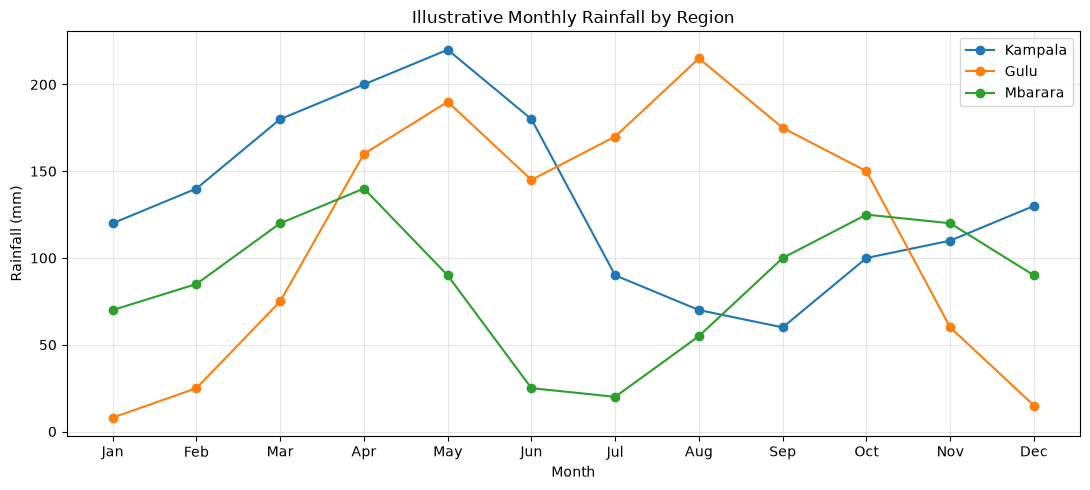

In [21]:
import matplotlib.pyplot as plt

# Plot each region's twelve monthly rainfall values.
fig, ax = plt.subplots(figsize=(11, 5))

for name, region in regions.items():
    ax.plot(months, region.rainfall, marker="o", label=name)

# Label the chart and show rainfall units.
ax.set_title("Illustrative Monthly Rainfall by Region")
ax.set_xlabel("Month")
ax.set_ylabel("Rainfall (mm)")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 6. Detect potential rainy-season peaks

We use scipy.signal.find_peaks with a minimum prominence of 30 mm
and a minimum separation of three months. Prominence measures how
strongly a peak stands above the surrounding lower rainfall values.

These are exploratory settings, not established climate thresholds.
We repeat the annual sequence to handle December–January continuity,
then retain only peaks from the central year.

One detected peak is labelled unimodal and two are labelled bimodal.
Local rainfall peaks do not necessarily represent separate rainy seasons,
so we will compare the results with published climate descriptions.

In [22]:
from scipy.signal import find_peaks

# Store detected peak months and the resulting classifications.
season_results = []

for name, region in regions.items():
    # Repeat the year so January and December have neighbouring months.
    repeated_rainfall = np.tile(region.rainfall, 3)

    # Find peaks with at least 30 mm prominence and three-month spacing.
    peaks, _ = find_peaks(
        repeated_rainfall,
        prominence=30,
        distance=3
    )

    # Keep the central year's peaks and convert to month positions.
    peak_months = peaks[(peaks >= 12) & (peaks < 24)] - 12

    # Classify the detected pattern without forcing every result.
    if len(peak_months) == 1:
        pattern = "Unimodal"
    elif len(peak_months) == 2:
        pattern = "Bimodal"
    else:
        pattern = f"{len(peak_months)} peaks — review needed"

    season_results.append({
        "Region": name,
        "Peak months": ", ".join(months[i] for i in peak_months),
        "Detected pattern": pattern
    })

display(pd.DataFrame(season_results))

,Region,Peak months,Detected pattern
0,Kampala,May,Unimodal
1,Gulu,"May, Aug",Bimodal
2,Mbarara,"Apr, Oct",Bimodal


### Compare detected peaks with Uganda's climate patterns

The World Bank's Climate Risk Country Profile describes two rainy
seasons across much of Uganda, broadly March–May and September–December,
and one extended March–October season in the northern region.

| Region | Detected pattern | Comparison with broad climate pattern |
|---|---|---|
| Kampala | Unimodal: May | Does not reproduce the expected southern bimodal pattern |
| Gulu | Bimodal: May and August | Two local peaks within the north's extended rainy season |
| Mbarara | Bimodal: April and October | Consistent with the broad southern pattern |

Kampala's illustrative series has only one peak meeting our settings.
Gulu's June dip separates two peaks mathematically, but rainfall remains
substantial between them. Therefore, two detected peaks do not necessarily
mean two distinct rainy seasons.

The results depend on the illustrative data and our prominence and
spacing settings. We retain the computed results and report the mismatch.
Reliable climate classification would require multiple years of
observations and consideration of the dry periods separating wet seasons.

Source: World Bank Group, Climate Risk Country Profile: Uganda,
Climate Baseline section.
https://climateknowledgeportal.worldbank.org/sites/default/files/2020-06/15464-WB_Uganda%20Country%20Profile-WEB_v1.pdf

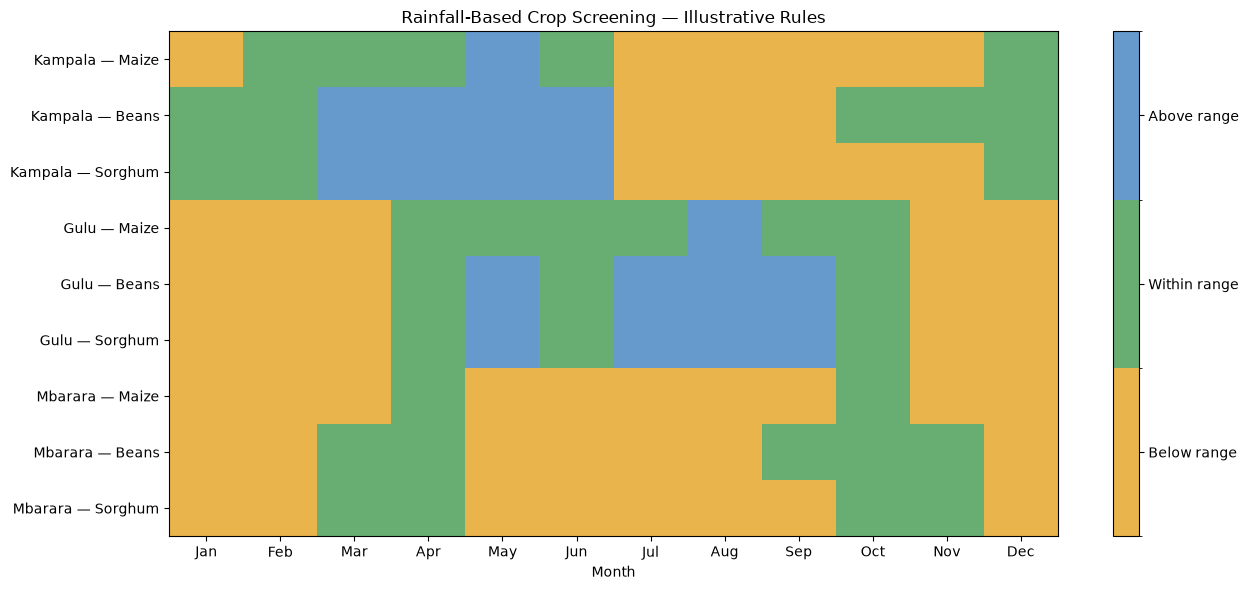

In [23]:
from matplotlib.colors import ListedColormap, BoundaryNorm

# Encode each region–crop combination across the twelve months.
heatmap_rows = []
row_labels = []

for region_name, region in regions.items():
    for crop_name, rule in crop_rules.items():
        codes = []

        for rainfall_mm in region.rainfall:
            category = rule.classify(float(rainfall_mm))

            # Use separate codes for below, within and above the range.
            if category == "Drought risk":
                codes.append(0)
            elif category == "Waterlogging risk":
                codes.append(2)
            else:
                codes.append(1)

        heatmap_rows.append(codes)
        row_labels.append(f"{region_name} — {crop_name}")

# Assign a distinct colour to each screening category.
colour_map = ListedColormap(["#e9b44c", "#68ad72", "#6699cc"])
colour_limits = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], colour_map.N)

fig, ax = plt.subplots(figsize=(13, 6))
heatmap = ax.imshow(
    heatmap_rows,
    cmap=colour_map,
    norm=colour_limits,
    aspect="auto"
)

# Label every month and region–crop combination.
ax.set_xticks(np.arange(12))
ax.set_xticklabels(months)
ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels)
ax.set_xlabel("Month")
ax.set_title("Rainfall-Based Crop Screening — Illustrative Rules")

# Explain colours without implying confirmed drought or waterlogging.
colour_bar = fig.colorbar(heatmap, ax=ax, ticks=[0, 1, 2])
colour_bar.ax.set_yticklabels([
    "Below range",
    "Within range",
    "Above range"
])

fig.tight_layout()
plt.show()

## 7. Advisory note for farmers in Mbarara

Based on this illustrative rainfall series, beans are a candidate for
planting around March or October, once adequate soil moisture is confirmed.
March–May totals 350 mm and October–December totals 335 mm, both within
FAO's indicative seasonal bean water requirement of 300–500 mm.

However, rainfall is not the same as water available to roots. May and
December each receive 90 mm, below our simplified monthly screening
range. Farmers should therefore consider moisture conservation and
monitor dry spells as the crop develops.

June and July are the driest months in this dataset, making them less
promising starting months for rain-fed beans. Good drainage also matters;
monthly totals alone cannot identify waterlogged fields.

This note is an exercise based on synthetic data, not a current planting
forecast. Before planting, confirm local rainfall onset, soil conditions,
variety duration and current guidance from an agricultural extension
officer.

Reference: FAO, Crop Water Needs, Table 14.
https://www.fao.org/4/s2022e/s2022e07.htm

## 8. Findings & Limitations

Kampala had the highest illustrative annual rainfall at 1,600 mm,
followed by Gulu at 1,388 mm and Mbarara at 1,040 mm. Gulu showed
the greatest variation between months, with a CV of 61.42%, compared
with 37.17% for Kampala and 42.48% for Mbarara. These values describe
within-year variation, not year-to-year reliability.

Our cosine similarity calculation matched SciPy for Kampala and Gulu.
Cosine similarity ignores overall rainfall scale, while Pearson correlation
compares co-variation and Euclidean distance captures differences in
monthly amounts. The measures therefore answer different questions.

Peak detection identified one peak for Kampala and two each for Gulu
and Mbarara. Only Mbarara clearly matched the broad expected seasonal
classification. Gulu's local peaks occur within an extended wet period,
showing why peak counts alone cannot reliably identify rainy seasons.

Crop screening used monthly ranges derived from FAO seasonal water
requirements and assumed growing durations. Beans were identified as
a candidate for March or October planting in Mbarara, subject to local
verification.

All rainfall values are synthetic. The crop rules ignore growth-stage
differences, soil moisture, runoff, irrigation and drainage. Above-range
rainfall does not establish waterlogging. Peak results also depend on
the chosen detection settings. The optional real-data extension was
not undertaken; at least ten years of observed or gridded rainfall
would help assess variability and strengthen the advisory.